# 02 — Batch pipeline: all participants → metrics.csv

This notebook runs the full preprocessing and metrics pipeline on all participants
(SZ and P groups) and exports a single flat CSV file ready for statistical analysis in R.

**Prerequisites:** run `01_exploration.ipynb` first to verify the pipeline works on individual participants.

**Output:** `results/metrics.csv` — one row per participant, one column per metric.

## 0. Imports

In [1]:
import sys
import os
import glob

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sources.config import ALL_SIGNAL_NAMES, FS, POSE_GLOB, FILE_METRICS
from sources.preprocessing import (
    parse_participant_info,
    build_wide_df,
    build_signals,
    normalize_signals,
    preprocess_signals,
)
from sources.metrics import (
    compute_extrema_metrics,
    motion_sum_for_marker,
    flatten_metrics,
)

print("Imports OK")

Imports OK


## 1. Discover all participant files

In [2]:
filepaths = sorted(glob.glob(POSE_GLOB))

print(f"Files found: {len(filepaths)}")
for fp in filepaths:
    print(f"  {os.path.relpath(fp, ROOT)}")

Files found: 40
  data\P\landmarks_P10_POSE.csv
  data\P\landmarks_P11_POSE.csv
  data\P\landmarks_P12_POSE.csv
  data\P\landmarks_P13_POSE.csv
  data\P\landmarks_P14_POSE.csv
  data\P\landmarks_P15_POSE.csv
  data\P\landmarks_P16_POSE.csv
  data\P\landmarks_P17_POSE.csv
  data\P\landmarks_P18_POSE.csv
  data\P\landmarks_P19_POSE.csv
  data\P\landmarks_P1_POSE.csv
  data\P\landmarks_P20_POSE.csv
  data\P\landmarks_P2_POSE.csv
  data\P\landmarks_P3_POSE.csv
  data\P\landmarks_P4_POSE.csv
  data\P\landmarks_P5_POSE.csv
  data\P\landmarks_P6_POSE.csv
  data\P\landmarks_P7_POSE.csv
  data\P\landmarks_P8_POSE.csv
  data\P\landmarks_P9_POSE.csv
  data\SZ\landmarks_SZ10_POSE.csv
  data\SZ\landmarks_SZ11_POSE.csv
  data\SZ\landmarks_SZ12_POSE.csv
  data\SZ\landmarks_SZ13_POSE.csv
  data\SZ\landmarks_SZ14_POSE.csv
  data\SZ\landmarks_SZ15_POSE.csv
  data\SZ\landmarks_SZ16_POSE.csv
  data\SZ\landmarks_SZ17_POSE.csv
  data\SZ\landmarks_SZ18_POSE.csv
  data\SZ\landmarks_SZ19_POSE.csv
  data\SZ\lan

## 2. Run the pipeline on all participants

In [3]:
all_rows = []
errors   = []

for filepath in filepaths:
    try:
        info         = parse_participant_info(filepath)
        df_raw       = pd.read_csv(filepath)
        df_w         = build_wide_df(df_raw)
        signals_raw  = build_signals(df_w)
        signals_norm = normalize_signals(signals_raw, df_w)
        signals_f    = preprocess_signals(signals_norm)
        frames_arr   = df_w["frame"].to_numpy()

        metrics = {
            name: compute_extrema_metrics(sig, frames_arr)
            for name, sig in signals_f.items()
        }

        row = flatten_metrics(
            metrics_dict     = metrics,
            participant_info = info,
            n_frames         = len(df_w),
            df_w             = df_w,
        )
        all_rows.append(row)

        n_avail = sum(row.get(f"{s}_available", 0) for s in ALL_SIGNAL_NAMES)
        print(f"[OK]    {info['participant_id']:8s}  —  {n_avail}/{len(ALL_SIGNAL_NAMES)} signals")

    except Exception as e:
        errors.append({"file": os.path.basename(filepath), "error": str(e)})
        print(f"[ERROR] {os.path.basename(filepath)} : {e}")

print(f"\nDone: {len(all_rows)} participants processed, {len(errors)} errors")

[OK]    P10       —  10/10 signals


[OK]    P11       —  10/10 signals
[OK]    P12       —  10/10 signals


[OK]    P13       —  10/10 signals
[OK]    P14       —  10/10 signals


[OK]    P15       —  10/10 signals
[OK]    P16       —  10/10 signals


[OK]    P17       —  10/10 signals
[OK]    P18       —  10/10 signals
[OK]    P19       —  10/10 signals


...

[OK]    SZ1       —  10/10 signals
[OK]    SZ20      —  10/10 signals


[OK]    SZ2       —  10/10 signals
[OK]    SZ3       —  10/10 signals


[OK]    SZ4       —  6/10 signals
[OK]    SZ5       —  10/10 signals


[OK]    SZ6       —  10/10 signals
[OK]    SZ7       —  10/10 signals


[OK]    SZ8       —  10/10 signals
[OK]    SZ9       —  10/10 signals

Done: 40 participants processed, 0 errors


## 3. Build results DataFrame

In [4]:
df_results = pd.DataFrame(all_rows)
df_results = df_results.sort_values(["group", "participant"]).reset_index(drop=True)

print(f"Shape: {df_results.shape[0]} participants x {df_results.shape[1]} columns")
print(f"\nGroups:")
print(df_results["group"].value_counts())

# Data availability per signal and group
print("\nData availability per signal (n participants with signal present):")
avail_df = df_results.groupby("group")[
    [f"{s}_available" for s in ALL_SIGNAL_NAMES]
].sum()
avail_df.columns = ALL_SIGNAL_NAMES
print(avail_df)

Shape: 40 participants x 110 columns

Groups:


group
P     20
SZ    20
Name: count, dtype: int64

Data availability per signal (n participants with signal present):
       left_hand_vertical  right_hand_vertical  left_hand_horizontal  \
group                                                                  
P                      20                   20                    20   
SZ                     19                   19                    19   

       right_hand_horizontal  swaying  sideways  head_horizontal  \
group                                                              
P                         20       20        20               20   
SZ                        19       20        20               20   

       head_vertical  left_foot_horizontal  right_foot_horizontal  
group                                                              
P                 20                    20                     20  
SZ                20                    20                     20  


## 4. Group visualization: boxplots SZ vs P

C:\Users\factory\AppData\Local\Temp\ipykernel_1328\3103836525.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=tick_labels,
C:\Users\factory\AppData\Local\Temp\ipykernel_1328\3103836525.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=tick_labels,
C:\Users\factory\AppData\Local\Temp\ipykernel_1328\3103836525.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=tick_labels,
C:\Users\factory\AppData\Local\Temp\ipykernel_1328\3103836525.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of bo

C:\Users\factory\AppData\Local\Temp\ipykernel_1328\3103836525.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=tick_labels,
C:\Users\factory\AppData\Local\Temp\ipykernel_1328\3103836525.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=tick_labels,
C:\Users\factory\AppData\Local\Temp\ipykernel_1328\3103836525.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=tick_labels,
C:\Users\factory\AppData\Local\Temp\ipykernel_1328\3103836525.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of bo

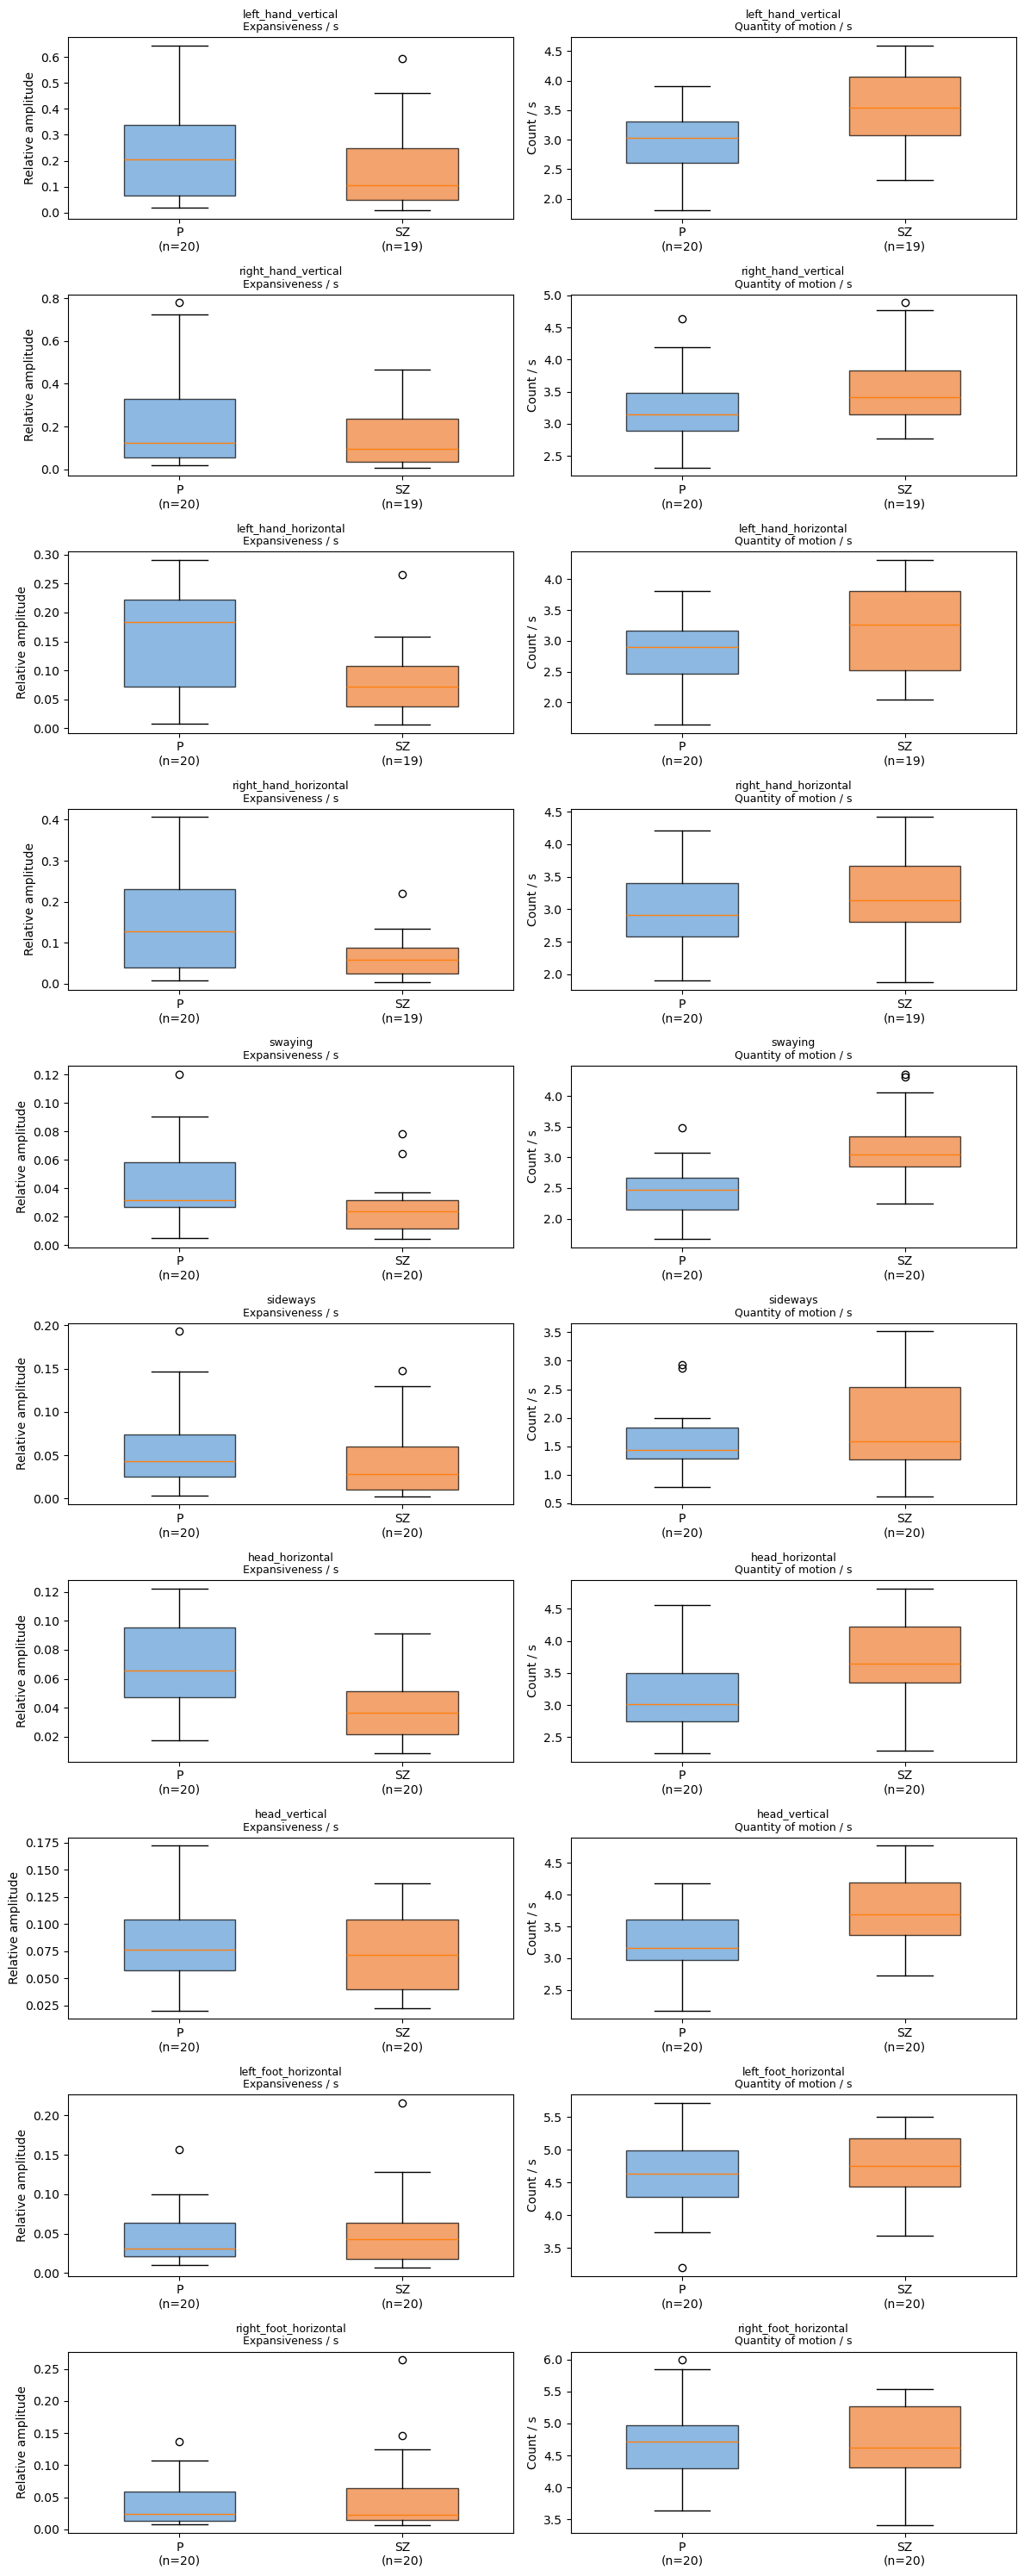

Figure saved to results/


In [5]:
metrics_to_plot = ["expansiveness_per_s", "quantity_of_motion_per_s"]
metric_labels   = {
    "expansiveness_per_s":      "Expansiveness / s",
    "quantity_of_motion_per_s": "Quantity of motion / s"
}

groups     = sorted(df_results["group"].unique())
colors     = {g: c for g, c in zip(groups, ["#5B9BD5", "#ED7D31"])}
n_signals  = len(ALL_SIGNAL_NAMES)

fig, axes = plt.subplots(n_signals, 2, figsize=(12, 3 * n_signals))
if n_signals == 1:
    axes = axes.reshape(1, 2)

for i, sig in enumerate(ALL_SIGNAL_NAMES):
    for j, metric in enumerate(metrics_to_plot):
        ax  = axes[i, j]
        col = f"{sig}_{metric}"

        if col not in df_results.columns:
            ax.set_visible(False)
            continue

        data_by_group = []
        tick_labels   = []
        box_colors    = []

        for grp in groups:
            vals    = df_results[df_results["group"] == grp][col].dropna()
            n_avail = int(df_results[df_results["group"] == grp][f"{sig}_available"].sum())
            data_by_group.append(vals)
            tick_labels.append(f"{grp}\n(n={n_avail})")
            box_colors.append(colors[grp])

        bp = ax.boxplot(data_by_group, labels=tick_labels,
                        patch_artist=True, widths=0.5)
        for patch, color in zip(bp["boxes"], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_title(f"{sig}\n{metric_labels[metric]}", fontsize=9)
        ax.set_ylabel("Relative amplitude" if "expansiveness" in metric else "Count / s")

plt.tight_layout()
plt.savefig(os.path.join(ROOT, "results", "group_boxplots.png"),
            dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved to results/")

## 5. Export to CSV

In [6]:
df_results.to_csv(FILE_METRICS, index=False)
print(f"Exported : {FILE_METRICS}")
print(f"Shape    : {df_results.shape[0]} rows x {df_results.shape[1]} columns")

if errors:
    errors_path = os.path.join(ROOT, "results", "batch_errors.csv")
    pd.DataFrame(errors).to_csv(errors_path, index=False)
    print(f"\nError log saved : {errors_path}")
    for e in errors:
        print(f"  {e['file']} : {e['error']}")
else:
    print("\nNo errors.")

Exported : c:\Users\factory\Desktop\pons.lea\results\metrics.csv
Shape    : 40 rows x 110 columns

No errors.
